# Few-Shot-Learning for Maize yield prediction in Ghana

In [ ]:
!pip install git+https://github.com/ScaleAGData/scaleag-vito.git@prometheo-integration --quiet

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.openeo.extract_sample_scaleag import generate_input_for_extractions, extract
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import finetune_on_task, load_finetuned_model, evaluate_finetuned_model, get_pretrained_model_url
from scaleagdata_vito.presto.inference import PrestoPredictor, reshape_result, plot_results
from scaleagdata_vito.utils.map import ui_map
from scaleagdata_vito.utils.dateslider import date_slider
from scaleagdata_vito.openeo.extract_sample_scaleag import collect_inputs_for_inference

### Before we start...

**Check your data!** Investigate validity of geometries uniqueness of sample IDs, presence of outliers and so on before starting the extraction. Achieving good performance making use of a limited amount of data is a challening task per se. Therefore, **the quality of your data will greatly impact your final results.**

Data requirements:
- Points or Polygons (will be aggregated in points)
- Lat-Lon (crs:4326) 
- Format: parquet, GeoJSON, shapefile, GPKG
For each geometry:
- Date (if available) 
- Unique ID
- Annotations

Good practice:

Remove polygons close to borders (e.g. apply buffer) to ensure data are contained in the field
If the annotations are accurate, point geometries should be preferred. However, especially in regression tasks (i.e., continuous output values) such us yield estimation the target values might be noisy. In that case, we recommend subdividing the polygons in subfields of 20m x 20m (to cover more measurements) and computing the median yield for a smoother and more reliable target

### 1) Presto datasets initialization

In [2]:
data_folder = Path.cwd().parent / "data/extractions/month"
composite_window = "month"
unique_id_column = "Field_ID"
target_name = 'Yield kg/H'

In [3]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2025-07-01", "2025-11-30"],
)
extraction_tuples = list(zip([extractions_2021, extractions_2022, extractions_2023, extractions_2025], [2021, 2022, 2023, 2025]))

  0%|          | 0/1 [00:00<?, ?it/s]

/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithC

#### Data investigation

In [4]:
# Specific for data used in this notebook
def correct_extractions(extractions):
    extraction_all = pd.DataFrame()
    for extraction, year in extractions:
        if year == 2022:
            extraction = extraction[extraction['Yield kg/H'] != 65535].reset_index(drop=True)
        extraction['year'] = year
        extraction["Field_ID"] = extraction['Field_ID'] + "_" + extraction['year'].astype(str)
        extraction['REGION'] = extraction['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
        extraction['DISTRICT'] = extraction['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
        extraction['COMMUNITY'] = extraction['COMMUNITY'].apply(lambda x: x.upper())
        extraction_all = pd.concat([extraction_all, extraction], ignore_index=True)
    return extraction_all

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram with bars next to each other
    bin_edges = np.histogram_bin_edges(
        pd.concat([train_df[target_column], test_df[target_column], val_df[target_column]]).dropna(), bins=20
    )

    width = 0.25
    # Plot histogram for Yield kg/H for each split using the same bin edges
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        hist, _ = np.histogram(data[target_column].dropna(), bins=bin_edges)
        # Use bin centers for bar positions
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        axes[0, 2].bar(bin_centers + i*width - width, hist, width=width, alpha=0.7, color=color, label=label, align='center')
        # x_ticks = [bin_centers + i*width]
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    # axes[0, 2].set_xticks(x_ticks)
    axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Bin mean yield and std plot
    bin_labels = ['Low', 'High'] if 'bin' in train_df.columns else train_df['bin'].unique().astype(str)
    x = np.arange(len(bin_labels))
    for idx, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        bin_means = data.groupby('bin')['Yield kg/H'].mean().reindex([0,1], fill_value=0)
        bin_stds = data.groupby('bin')['Yield kg/H'].std().reindex([0,1], fill_value=0)
        axes[1, 2].bar(x + idx*width, bin_means.values, width=width, yerr=bin_stds.values, capsize=5, color=color, alpha=0.8, label=label)

    axes[1, 2].set_title('Bin Mean Yield ± Std')
    axes[1, 2].set_xlabel('Bin')
    axes[1, 2].set_ylabel('Mean Yield (kg/H)')
    axes[1, 2].set_xticks(x + width)
    axes[1, 2].set_xticklabels(bin_labels)
    axes[1, 2].legend()
    # # Remove the empty subplot
    # axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

In [5]:
extractions = correct_extractions(extraction_tuples)

we divide the data in High and Low yield classes by taking the setting the threshold on the peak of the global data distribution

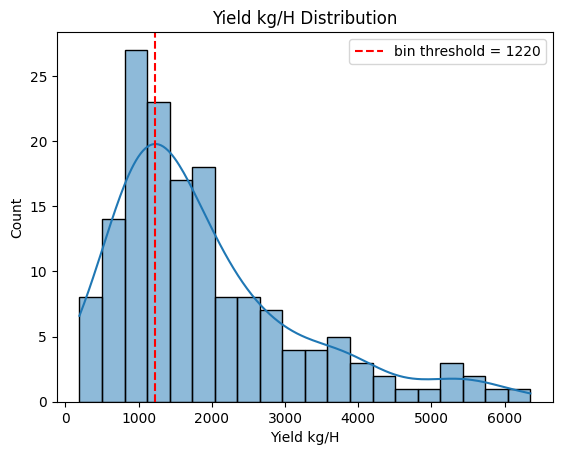

In [6]:
bin_th = 1220
sns.histplot(extractions['Yield kg/H'], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

we now binarize the target and divide our data making sure the proportion of low and high yield data are represented in all the splits

In [7]:
from sklearn.model_selection import train_test_split

def binarize_target_and_split_data(extractions, target_column, unique_id_column, bin_th):
    # Create bins for stratification based on the parent group's median yield
    extractions['bin'] = extractions[target_column].apply(lambda x: 0 if x < bin_th else 1)

    # Filter out yield bins with less than 3 samples to avoid stratification issues
    bin_counts = extractions['bin'].value_counts()
    valid_bins = bin_counts[bin_counts >= 3].index
    extractions_filtered = extractions[extractions['bin'].isin(valid_bins)]

    # Compute mean and std of yield for each bin and add as columns
    bin_stats = extractions_filtered.groupby('bin')[target_column].agg(['mean', 'std']).rename(columns={'mean': 'bin_mean_yield', 'std': 'bin_std_yield'})
    extractions_filtered = extractions_filtered.merge(bin_stats, left_on='bin', right_index=True, how='left')

    print(f"Original parent groups: {len(extractions)}")
    print(f"After filtering bins with <3 samples: {len(extractions_filtered)}")
    print(f"Removed {len(extractions) - len(extractions_filtered)} parent groups")

    # Get unique parentnames as our splitting units (from filtered data)
    parentnames = extractions_filtered[unique_id_column].unique().tolist()
    yield_bins = extractions_filtered['bin'].values

    # First split: 80% train, 20% temp (for val and test)
    train_parents, temp_parents = train_test_split(
        parentnames,
        train_size=0.8,
        stratify=yield_bins,
        random_state=42
    )

    # Get yield bins for temp parents and check if they still have enough samples for stratification
    temp_bins = extractions_filtered[extractions_filtered[unique_id_column].isin(temp_parents)]['bin'].values
    temp_bin_counts = pd.Series(temp_bins).value_counts()

    # Check if any bin in temp set has less than 2 samples (minimum for stratification)
    if (temp_bin_counts < 2).any():
        print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
        # Second split: split temp randomly into 50-50 for val and test
        val_parents, test_parents = train_test_split(
            temp_parents,
            train_size=0.5,
            random_state=42
        )
    else:
        # Second split: split temp into 50-50 for val and test with stratification
        val_parents, test_parents = train_test_split(
            temp_parents,
            train_size=0.5,
            stratify=temp_bins,
            random_state=42
        )

    # Create the final datasets by filtering on parentname
    train_df = extractions_filtered[extractions_filtered[unique_id_column].isin(train_parents)]
    val_df = extractions_filtered[extractions_filtered[unique_id_column].isin(val_parents)]
    test_df = extractions_filtered[extractions_filtered[unique_id_column].isin(test_parents)]

    print(f"Train set size: {len(train_df)} ({len(train_df)/len(extractions_filtered)*100:.1f}%)")
    print(f"Validation set size: {len(val_df)} ({len(val_df)/len(extractions_filtered)*100:.1f}%)")
    print(f"Test set size: {len(test_df)} ({len(test_df)/len(extractions_filtered)*100:.1f}%)")

    # Verify no parentname overlap
    assert len(set(train_df[unique_id_column]) & set(val_df[unique_id_column])) == 0
    assert len(set(train_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
    assert len(set(val_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
    print(f"✓ No {unique_id_column} overlap between splits")
    return train_df, val_df, test_df

train_df, val_df, test_df = binarize_target_and_split_data(extractions, target_name, unique_id_column, bin_th)

Original parent groups: 157
After filtering bins with <3 samples: 157
Removed 0 parent groups
Train set size: 125 (79.6%)
Validation set size: 16 (10.2%)
Test set size: 16 (10.2%)
✓ No Field_ID overlap between splits


/tmp/ipykernel_1851997/2959583095.py:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])


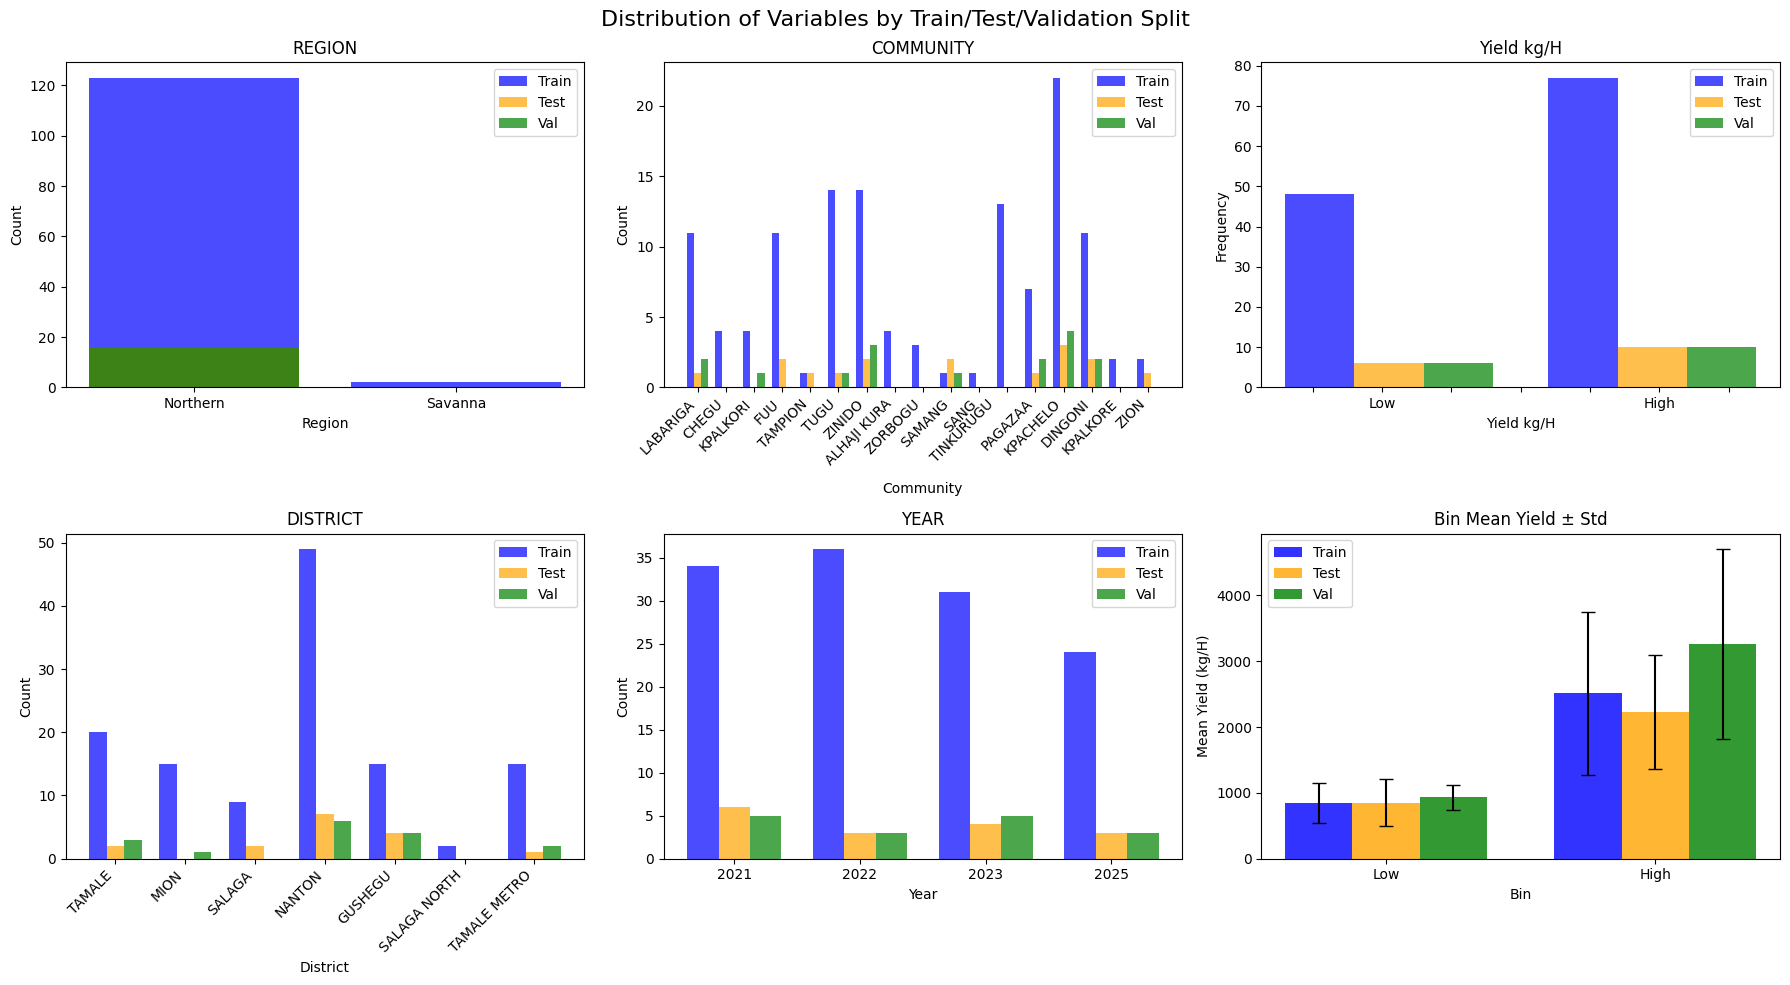

In [8]:
plot_distribution(train_df, test_df, val_df, 'bin')

We Initialize the training, validation and test datasets objects to be used for training Presto.

In [9]:
target_name = "bin"
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"

In [10]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

### 3) Presto Finetuning

In this section Presto will be Fine-Tuned in a supervised way for the target downstream task. first we set up the following experiment parameters:

- `output_dir` : where to dave the model 
- `experiment_name` : the model name

In [11]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("./models/")
experiment_name = f"presto-ft-{composite_window}-geomaize-bin"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32 
num_workers = 0
max_epochs = 100  # Keep reasonable number of epochs
patience = 100  # More patience for convergence

In [12]:
from scaleagdata_vito.presto.utils import get_pretrained_model_url

loss_fn = nn.BCEWithLogitsLoss()


pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )


learning_rate = 1e-3
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=learning_rate)

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=learning_rate,
)

scheduler = lr_scheduler.ConstantLR(optimizer, factor=1.0)
# scheduler_plateau = lr_scheduler.ReduceLROnPlateau(optimizer, factor=drop_factor, min_lr=end_lr)
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
)

2026-03-13 13:08:18.141 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/git/GEOMaize/notebooks/models/presto-ft-month-geomaize-bin


Finetuning:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 13:08:18.427 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/100: Epoch 1/100 | Train Loss: 0.6840 | Val Loss: 0.6629 | Best Loss: 0.6629 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-03-13 13:08:43.709 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 98/100: Epoch 98/100 | Train Loss: 0.1096 | Val Loss: 1.1738 | Best Loss: 0.6232 (no improvement for 34 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 13:08:43.923 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 99/100: Epoch 99/100 | Train Loss: 0.0861 | Val Loss: 1.0430 | Best Loss: 0.6232 (no improvement for 35 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 13:08:44.132 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 100/100: Epoch 100/100 | Train Loss: 0.0912 | Val Loss: 0.9034 | Best Loss: 0.6232 (no improvement for 36 epochs)
2026-03-13 13:08:44.962 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [16]:
# save datasets for future use
train_df.to_parquet(model_output_dir / "train_df.parquet")
val_df.to_parquet(model_output_dir / "val_df.parquet")
test_df.to_parquet(model_output_dir / "test_df.parquet")

In [13]:
# Get predictions for train and validation sets as well
train_metrics, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

test_metrics, test_preds_presto, test_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

2026-03-13 13:08:51.405 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-13 13:08:51.508 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-13 13:08:51.529 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task


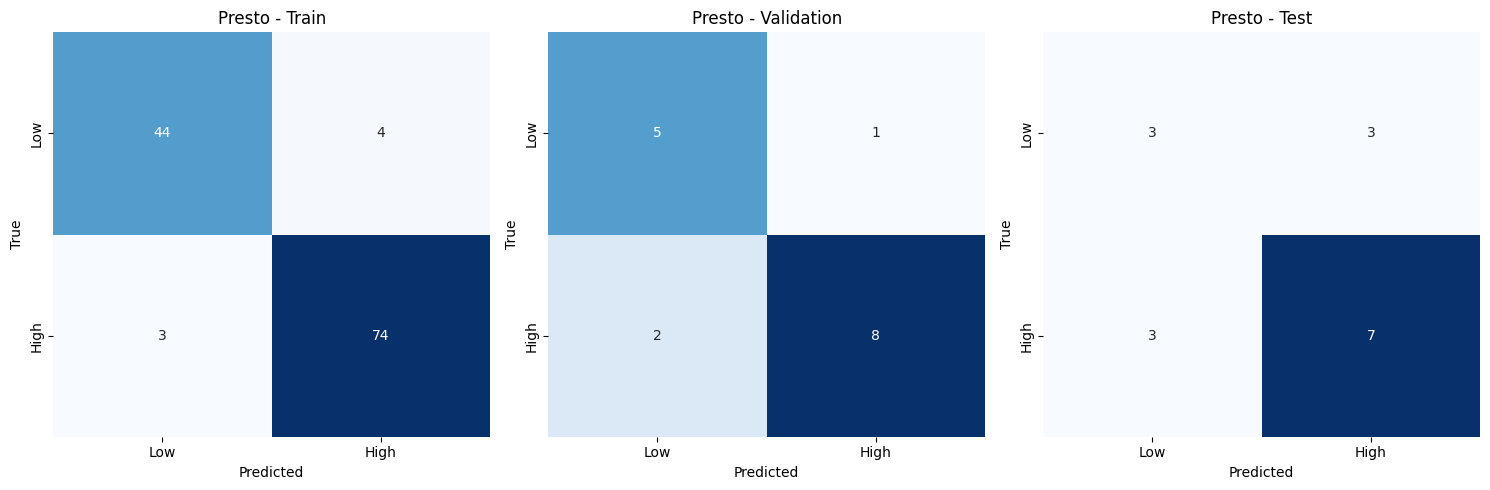

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare predictions and true labels for each model and split
model_name = "Presto"
split_names = ["Train", "Validation", "Test"]
model_preds = [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)]
model_trues = [train_targets_presto, val_targets_presto, test_targets_presto]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, split_name in enumerate(split_names):
    y_true = model_trues[col]
    y_pred = model_preds[col]
    # Convert boolean to int if needed
    if y_pred.dtype == bool:
        y_pred = y_pred.astype(int)
    if y_true.dtype == bool:
        y_true = y_true.astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[col], cbar=False,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"])
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('True')
    axes[col].set_title(f"{model_name} - {split_name}")

plt.tight_layout()
plt.show()

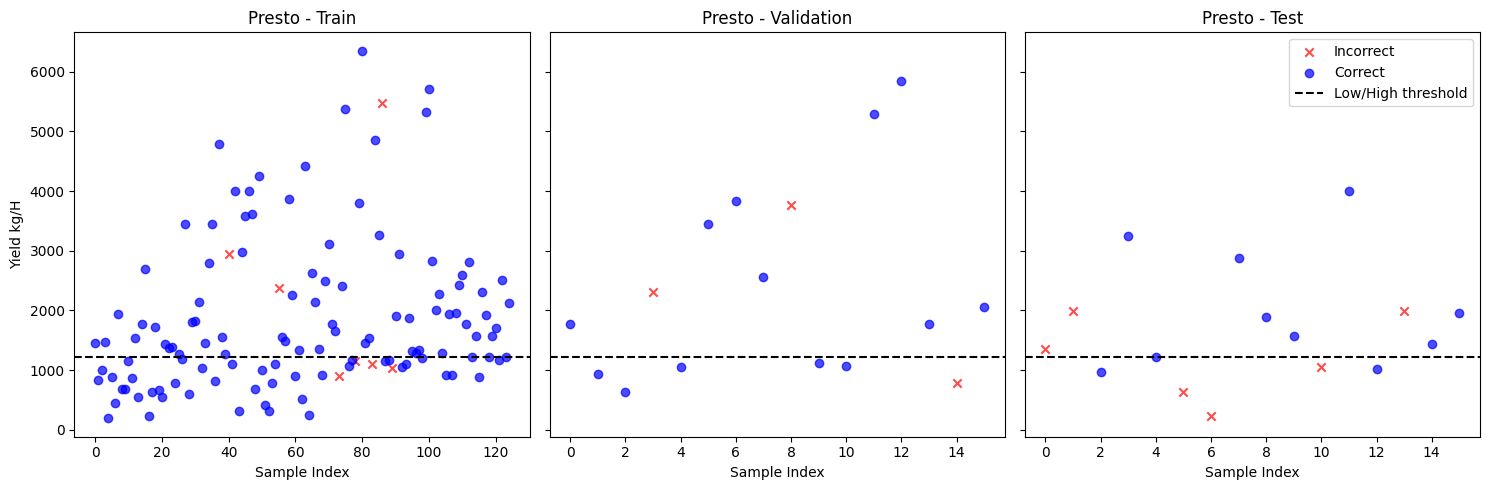

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = [
    (
        "Presto",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
]

col_titles = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=True)

for row, (model_name, y_trues, y_preds, yields) in enumerate(plot_data):
    for col in range(3):
        ax = axes[col]
        y_true = y_trues[col]
        y_pred = y_preds[col]
        yield_vals = yields[col]
        correct = (y_true == y_pred)
        # Plot correct in blue, incorrect in red
        ax.scatter(
            np.arange(len(yield_vals))[~correct], yield_vals[~correct], 
            c="red", label="Incorrect", alpha=0.7, marker="x"
        )
        ax.scatter(
            np.arange(len(yield_vals))[correct], yield_vals[correct], 
            c="blue", label="Correct", alpha=0.7, marker="o"
        )
        # Draw the bin threshold line and always show its label in the legend
        ax.axhline(bin_th, color="black", linestyle="--", label="Low/High threshold")
        ax.set_title(f"{model_name} - {col_titles[col]}")
        ax.set_xlabel("Sample Index")
        if col == 0:
            ax.set_ylabel("Yield kg/H")
        if row == 0 and col == 2:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 4) Inference using Fine-Tuned end-to-end Presto

In this section, we apply the fine tuned model to generate a yield map on an unseen area. 
We need to indicate the spatial and temporal extent. The 2 cells below, offer a simple way for the user to provide these information and perform once again the extraction from CDSE of the EO time-series required by Presto. 
We also need to indicate the `output_dir` of where to save the datacube of the extraction, its `output_filename` and the `composite_window` which will be the same as used for finetuning the model.

In [ ]:
map = ui_map(area_limit=7)

In [ ]:
# select 1 year of data
slider = date_slider()

In [ ]:
output_dir = Path("/home/giorgia/Private/data/geomaize/regression")
output_filename = "inference_area"
inference_file = output_dir / f"{output_filename}.nc"

In [ ]:
collect_inputs_for_inference(
    spatial_extent=map.get_extent(),
    temporal_extent=slider.get_processing_period(),
    output_path=output_dir,
    output_filename=f"{output_filename}.nc",
    composite_window=composite_window,
)

Once the datacube has been extracted, we can perform the inference task using the finetuned model and visualize the predicted map. 

In [ ]:
inference_file = output_dir / "inference_area.nc"
mask_path = None

In [ ]:
finetuned_model = load_finetuned_model(model_output_dir / experiment_name, task_type=task_type)
presto_model = PrestoPredictor(
    model=finetuned_model,
    batch_size=50,
    task_type=task_type,
    composite_window=composite_window,
)

predictions = presto_model.predict(
    inference_file, 
    mask_path=mask_path,
    )
predictions_map = reshape_result(predictions, path_to_input_file=inference_file)

In [ ]:
plot_results(prob_map=predictions_map, path_to_input_file=inference_file, task=task_type, ts_index=16)